In [219]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance_nd as wasserstein
from nested_sampler import NestedSampler
import pandas as pd
import math
%config InlineBackend.figure_formats = ["retina"] # high resolution in plots
# Figures are saved into a local clone of the GitHub repository of the thesis document:
from pathlib import Path
FIGURES_DIR = Path(r"C:\Users\kr326\Documents\MScThesis\figures")

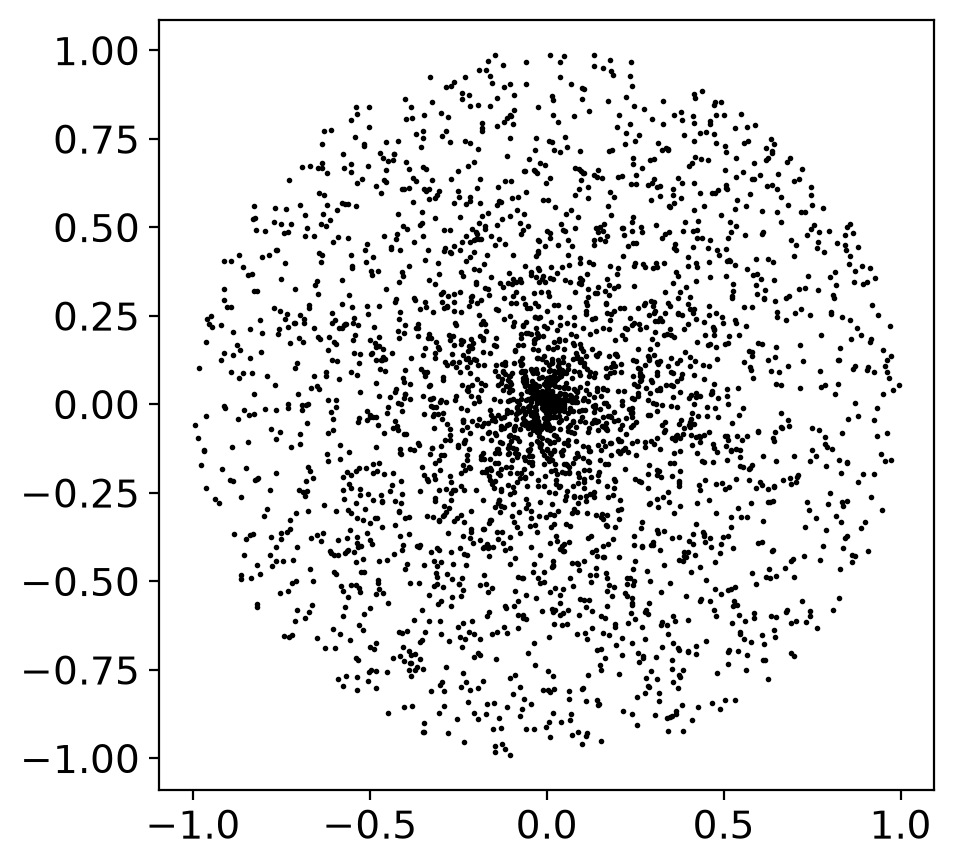

In [188]:
fig, ax = plt.subplots(figsize=(5, 5))
NPTS = 3000
np.random.seed(42)
pts = np.random.random([NPTS,2])
xy_pts = []
for p in pts:
    angle_, radius = p
    angle = angle_ * 2 * np.pi
    x = np.cos(angle) * radius
    y = np.sin(angle) * radius
    xy_pts.append([x, y])
xy_pts = np.array(xy_pts)
ax.scatter(xy_pts[:, 0], xy_pts[:, 1], color='k', s=1)
plt.show()

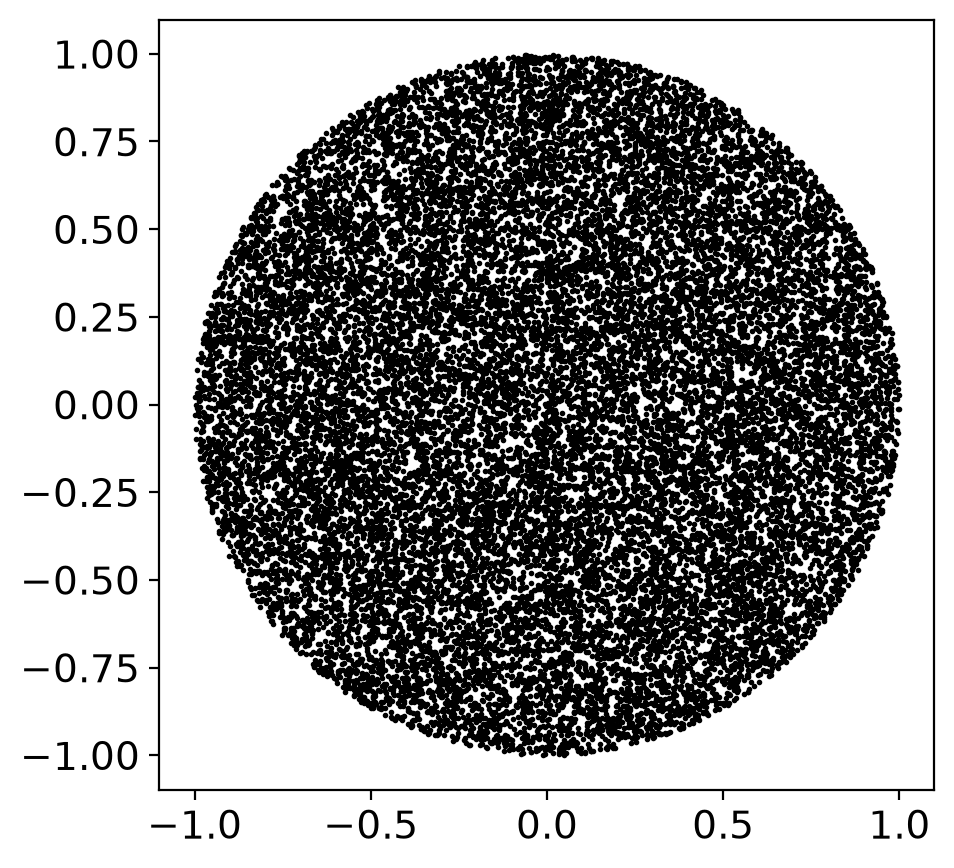

In [189]:
fig, ax = plt.subplots(figsize=(5, 5))
NPTS = 30000
np.random.seed(42)
pts = np.random.random([NPTS,2])
pts = 2 * pts - np.array([1, 1])
xy_pts = []
for p in pts:
    if np.sqrt(p[0] ** 2 + p[1]**2) < 1:
        xy_pts.append(p)
xy_pts = np.array(xy_pts)
ax.scatter(xy_pts[:, 0], xy_pts[:, 1], color='k', s=1)
plt.show()

In [8]:
from scipy.spatial import ConvexHull

In [9]:
area = ConvexHull(xy_pts).volume
circum = ConvexHull(xy_pts).area
print(f"area {area:.2f}, error, {np.abs(area - np.pi)/(2 * np.pi):.3f}")
print(f"circumference {circum:.2f} error {np.abs(2 * np.pi - circum)/(2 * np.pi):.3f}")

area 3.13, error, 0.002
circumference 6.27 error 0.001


> Illustrations of Nested Sampling

In [82]:
def eucl_dist_2d(x0, x1):
    return np.sqrt(x0**2 + x1**2)

In [220]:
NUM_LIVE = 1024
def circle_constraint(x, radius = 1):
    """2-dimensional circle constraints"""
    x1, x2 = x
    return np.sqrt(x1 ** 2 + x2 ** 2) - radius

circ_results = NestedSampler(circle_constraint, lb=[-1, -1], ub=[1, 1], num_live=NUM_LIVE, num_prop=16, display_iter=1).sample()
print(circ_results.summary())

def square_constraint(x, sidelength = 0.5):
    """square constraint"""
    return np.abs(x[0]) - sidelength, np.abs(x[1]) - sidelength

square_results = NestedSampler(square_constraint, lb=[-1, -1], ub=[1, 1], num_live=NUM_LIVE, num_prop=16, display_iter=1).sample()
print(square_results.summary())

def triangle_constraint(x, l = 0.5):
    """triangle constraint"""
    return -l - x[1], 1.5 * x[0] + x[1] -l, -1.5 * x[0] + x[1] - l

triangle_results = NestedSampler(triangle_constraint, lb=[-1, -1], ub=[1, 1], num_live=NUM_LIVE, num_prop=16, display_iter=1).sample()
print(triangle_results.summary())

def band_constraint(x, c=0.5, w=0.15):
    """parabolic band: |x1 - (x0^2 - c)| <= w, split into two smooth constraints"""
    center = x[0] ** 2 - c
    return x[1] - center - w, center - x[1] - w

band_results = NestedSampler(band_constraint, lb=[-1, -1], ub=[1, 1], num_live=NUM_LIVE, num_prop=16, display_iter=1).sample()
print(band_results.summary())


def components_constraint(x, a=(-0.5, -0.4), ra=0.35, b=(0.5, 0.5), rb=0.2):
    """union of two disks of different size (min of distances -> union)"""
    ga = eucl_dist_2d(x[0] - a[0], x[1] - a[1]) - ra
    gb = eucl_dist_2d(x[0] - b[0], x[1] - b[1]) - rb
    return min(ga, gb)

components_results = NestedSampler(components_constraint, lb=[-1, -1], ub=[1, 1], num_live=NUM_LIVE, num_prop=16, display_iter=1).sample()
print(components_results.summary())


** INITIALIZING LIVE POINTS (1024)      0.00 SEC

Iterate        Contour #Feas    #Dead         Factor
----------------------------------------------------
      0     4.0317e-01   814        0     3.0000e-01
      1     2.9121e-01   828       16     2.9912e-01
      2     2.3749e-01   842       32     2.9819e-01
      3     1.9211e-01   855       46     2.9737e-01
      4     1.6994e-01   869       62     2.9645e-01
      5     1.6011e-01   879       77     2.9558e-01
      6     1.3370e-01   888       90     2.9483e-01
      7     1.1192e-01   902      105     2.9397e-01
      8     9.6693e-02   918      121     2.9305e-01
      9     8.4380e-02   932      135     2.9225e-01
     10     6.6217e-02   947      151     2.9134e-01
     11     5.8489e-02   959      164     2.9060e-01
     12     4.8851e-02   970      178     2.8981e-01
     13     3.7622e-02   986      194     2.8890e-01
     14     2.7226e-02   998      206     2.8823e-01
     15     2.0302e-02  1012      220     2.8744

Text(0, 0.5, '$d_2$')

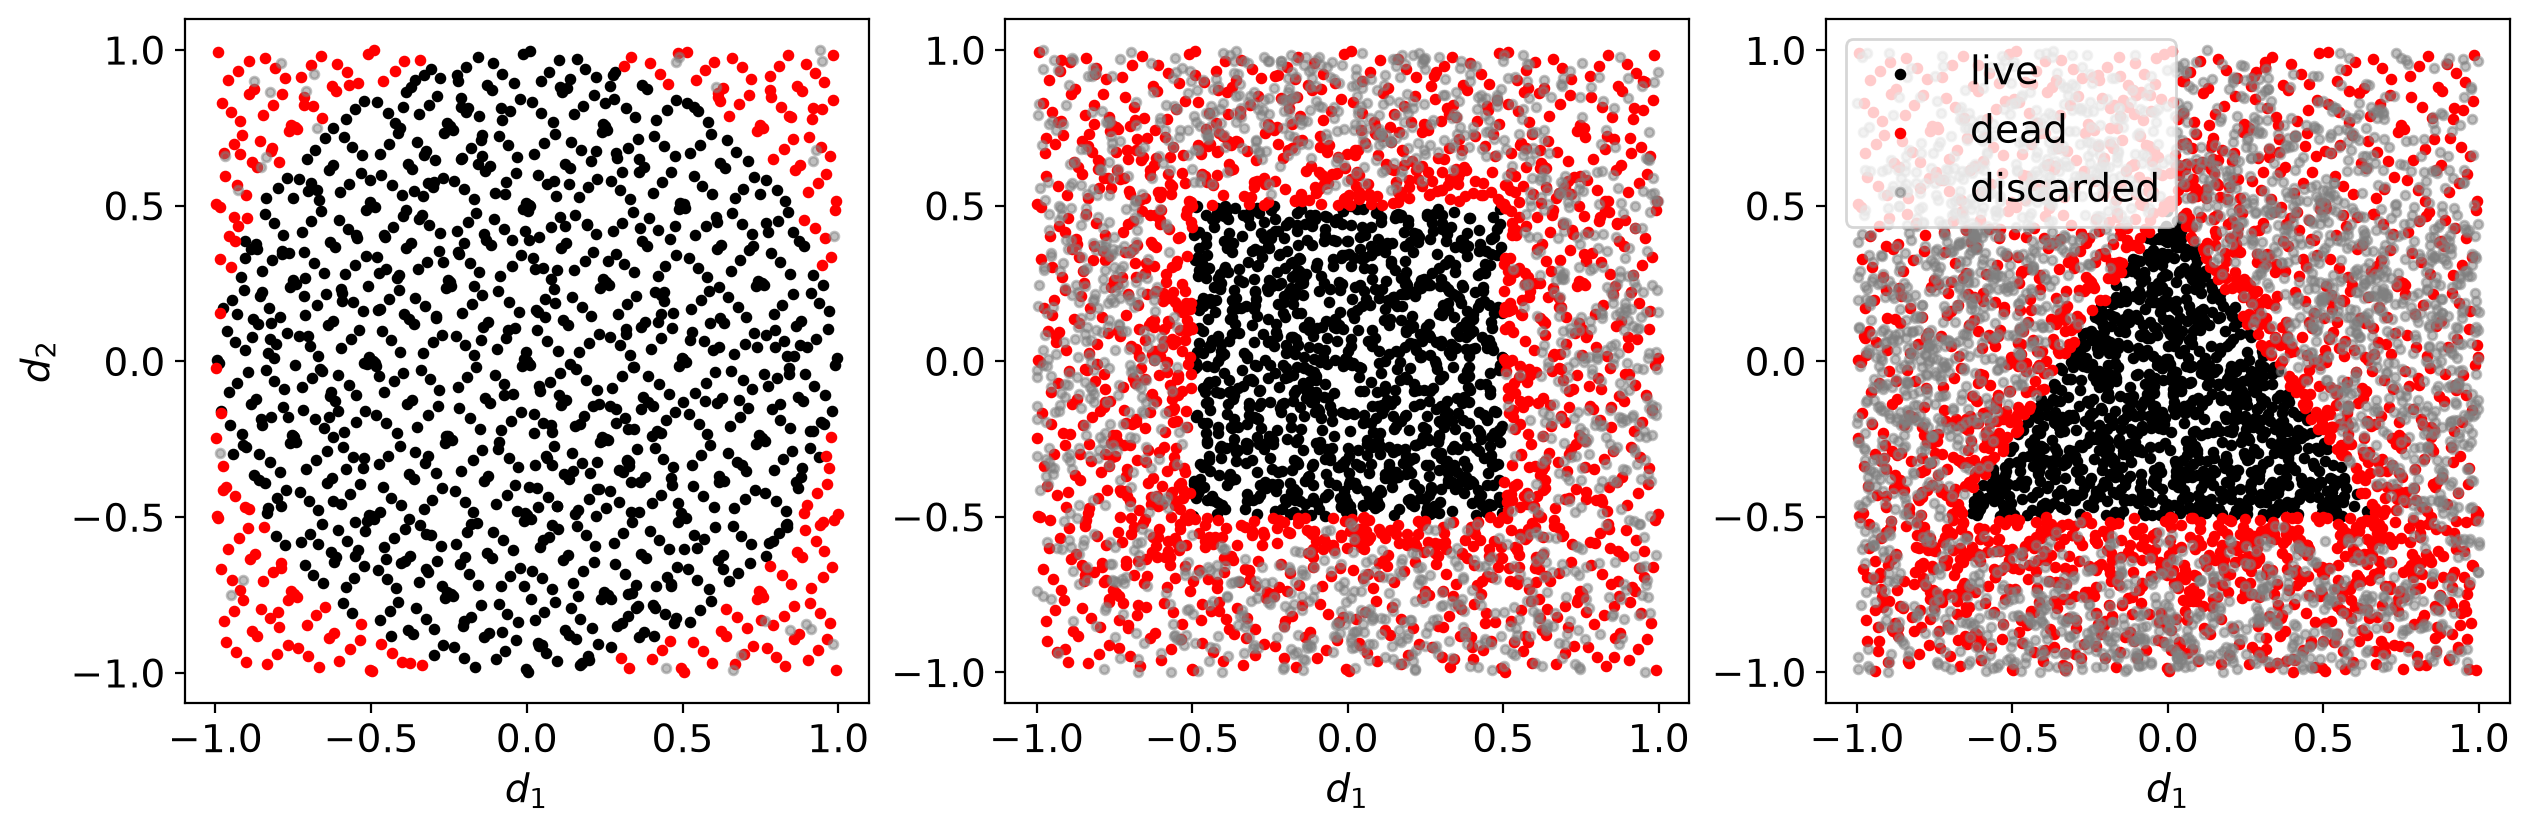

In [221]:
def scatter_results(results, ax):
    ax.scatter(results.live.x[:, 0], results.live.x[:, 1], s=10, color='k', label='live')
    ax.scatter(results.dead.x[:, 0], results.dead.x[:, 1], s=10, color='r', label='dead')
    ax.scatter(results.discarded.x[:, 0], results.discarded.x[:, 1], s=10, color='gray', alpha=0.5, label='discarded')
    ax.set_xlabel("$d_1$")
    ax.set_aspect(1)

fig, axs = plt.subplots(1, 3, figsize=(15, 8))
scatter_results(circ_results, axs[0])
scatter_results(square_results, axs[1])
scatter_results(triangle_results, axs[2])
axs[2].legend()
axs[0].set_ylabel("$d_2$")

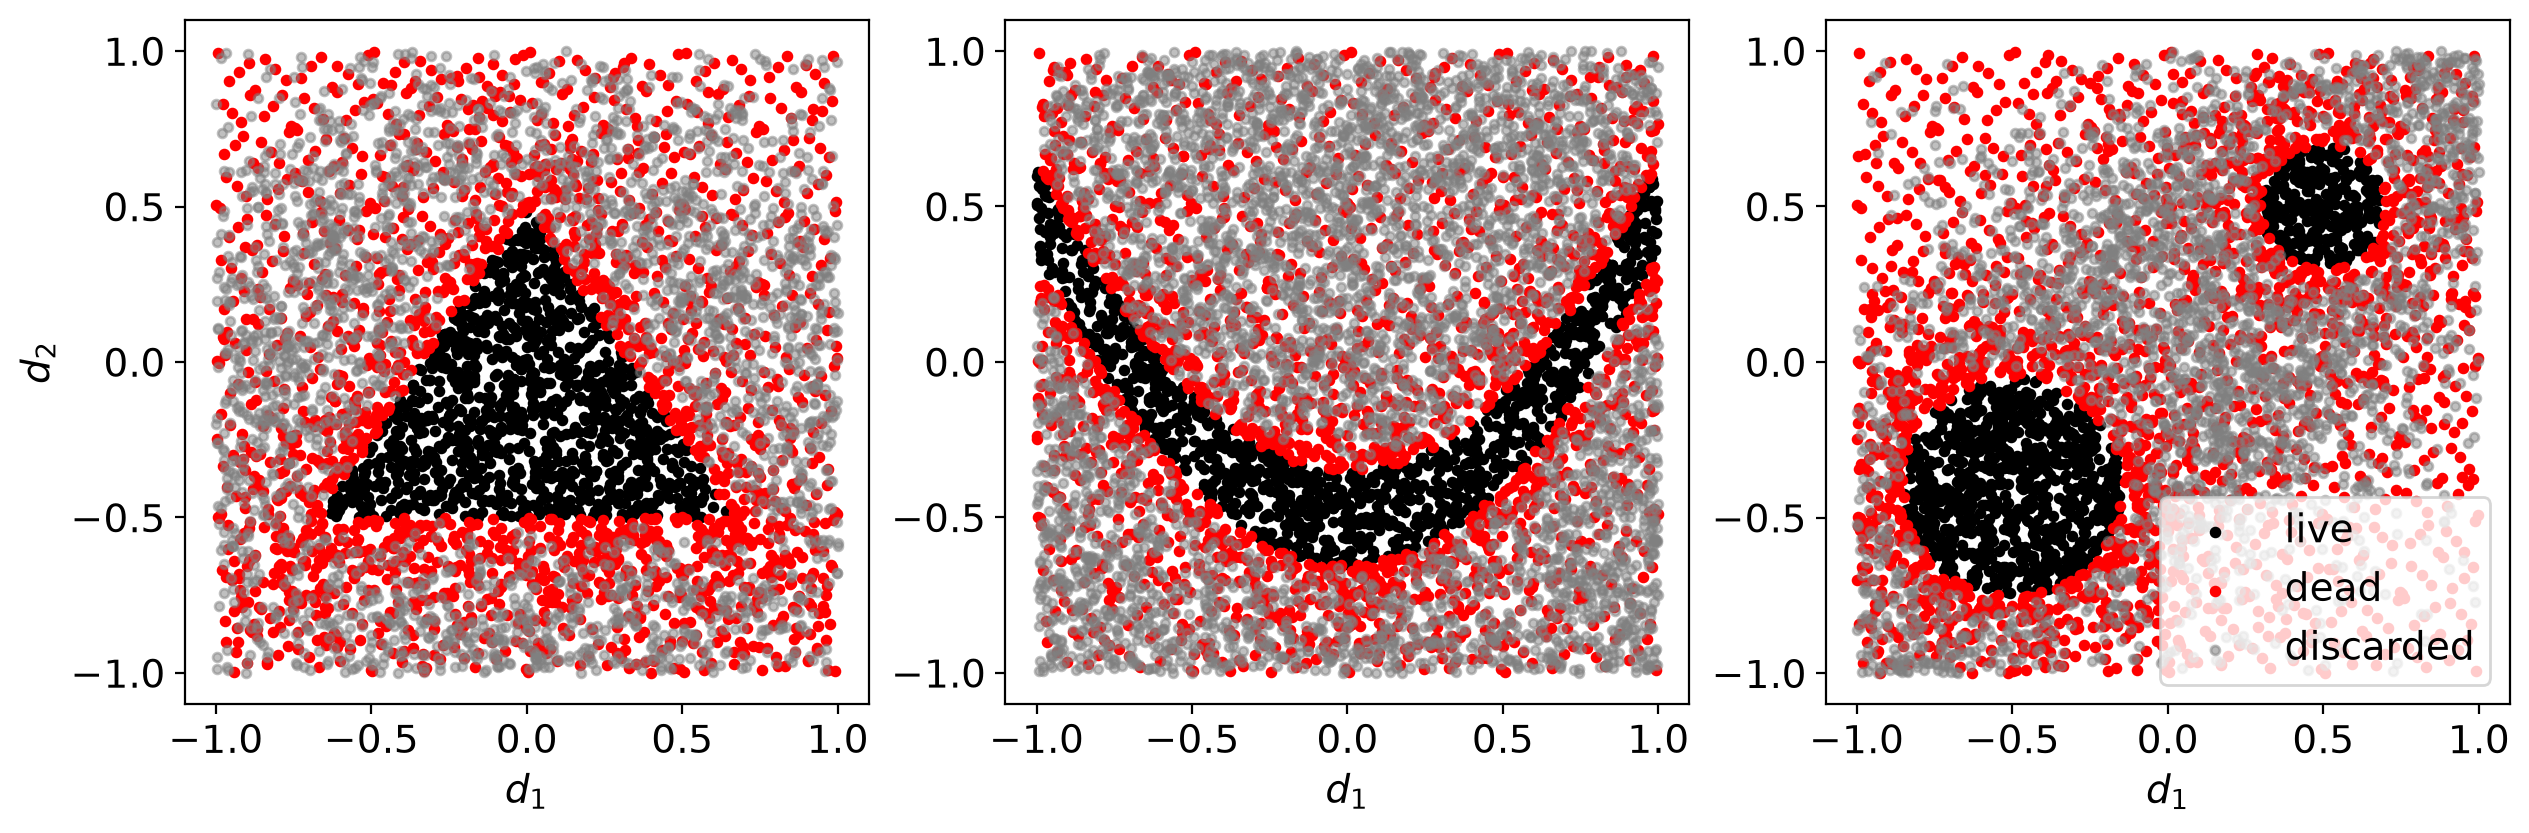

In [222]:
fig, axs = plt.subplots(1, 3, figsize=(15, 8))
scatter_results(triangle_results, axs[0])
scatter_results(band_results, axs[1])
scatter_results(components_results, axs[2])
axs[2].legend()
axs[0].set_ylabel("$d_2$")
fig.savefig(FIGURES_DIR / "Introduction/NSIllustrations.png", dpi=300, bbox_inches="tight")

In [ ]:
circ_results.dead.x

array([[-0.9921875 ,  0.9921875 ],
       [ 0.9921875 , -0.9921875 ],
       [ 0.984375  ,  0.984375  ],
       [-0.96679688, -0.90039062],
       [-0.90039062, -0.96679688],
       [-0.93359375, -0.93359375],
       [-0.95898438,  0.90429688],
       [ 0.90429688, -0.95898438],
       [ 0.93359375, -0.92578125],
       [-0.92578125,  0.93359375],
       [ 0.96289062, -0.89257812],
       [-0.89257812,  0.96289062],
       [ 0.95507812,  0.89648438],
       [ 0.89648438,  0.95507812],
       [ 0.92578125,  0.92578125],
       [ 0.83789062,  0.98242188],
       [ 0.98242188,  0.83789062],
       [-0.84179688,  0.97460938],
       [ 0.97460938, -0.84179688],
       [ 0.83007812, -0.97851562],
       [-0.97851562,  0.83007812],
       [-0.83398438, -0.97070312],
       [-0.97070312, -0.83398438],
       [ 0.80859375,  0.94921875],
       [ 0.94921875,  0.80859375],
       [-0.94921875,  0.80078125],
       [ 0.80078125, -0.94921875],
       [-0.80859375,  0.94140625],
       [ 0.94140625,

In [87]:
df_circ = circ_results.to_dataframe()

In [88]:
import numpy as np
from nested_sampler import NestedSampler

def constraints(d, p=None):
    p0 = 1.0 if p is None else p[0]
    y = p0 * d[0] ** 2 + d[1]
    return [y - 0.75, 0.20 - y]        # feasible iff every value <= 0

# Nominal parameter
result = NestedSampler(constraints, lb=[-1, -1], ub=[1, 1], num_live=500).sample()
print(result.summary())
result.live.x          # (500, 2) live points, all feasible when result.converged
result.live.value      # their criterion (max constraint value), ascending
result.dead.x          # dead points in order of death
result.discarded.x     # rejected proposals
result.history.contour # contour level per iteration
result.save("run.npz") # Result.load("run.npz") reads it back



** INITIALIZING LIVE POINTS (500)      0.00 SEC

Iterate        Contour #Feas    #Dead         Factor
----------------------------------------------------
      0     1.2266e+00   131        0     3.0000e-01
     25     2.6660e-01   252      295     2.6672e-01
     50     1.0763e-01   354      484     2.4730e-01
     75     1.8346e-02   469      619     2.3430e-01
     81     0.0000e+00   500      651     2.3132e-01
status:      NORMAL
iterations:  81
evaluations: 1796 (0 failed)
wall time:   0.01 s
live:        500 points, 500 feasible, contour 0.0000e+00
dead:        651 points
discarded:   645 points


In [89]:
result.live

PointSet(x=array([[ 0.91505425, -0.36304938],
       [ 0.10546875,  0.46484375],
       [ 0.8125    , -0.1875    ],
       [ 0.26449916,  0.40202704],
       [ 0.90727098, -0.34352256],
       [-0.91111245, -0.36004113],
       [-0.06684302,  0.46553308],
       [-0.4079414 ,  0.31424019],
       [-0.95782309, -0.43669128],
       [-0.10546875,  0.45703125],
       [-0.66096415,  0.04498799],
       [-0.29853948,  0.39320807],
       [-0.22265625,  0.41796875],
       [-0.671875  ,  0.015625  ],
       [ 0.06411997,  0.47923455],
       [-0.35523933,  0.35727286],
       [-0.44755099,  0.28346912],
       [-0.06475812,  0.4617009 ],
       [-0.93383134, -0.40692017],
       [-0.2441808 ,  0.40526387],
       [-0.65191075,  0.03976125],
       [ 0.6640625 ,  0.0234375 ],
       [ 0.55176227,  0.18179125],
       [ 0.29571182,  0.39900044],
       [-0.67238962,  0.03467736],
       [-0.92217265, -0.38722598],
       [-0.482363  ,  0.23036612],
       [-0.68459735,  0.01941652],
       [ 

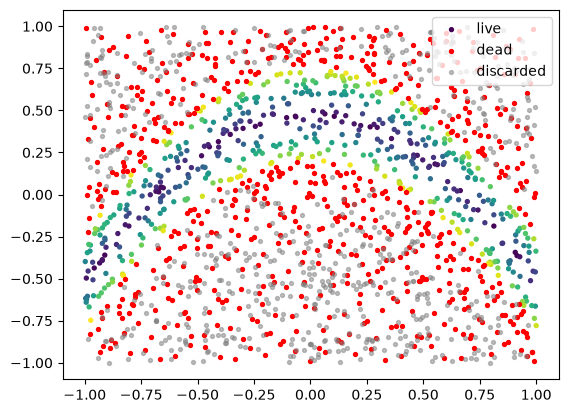

In [90]:
import matplotlib.pyplot as plt
plt.scatter(result.live.x[:, 0], result.live.x[:, 1], label="live", s=8, cmap="viridis", c=result.live.value)
plt.scatter(result.dead.x[:, 0], result.dead.x[:, 1], label="dead", s=8, color="red")
plt.scatter(result.discarded.x[:, 0], result.discarded.x[:, 1], label="discarded", s=8, color="grey", alpha=0.5)
plt.legend()

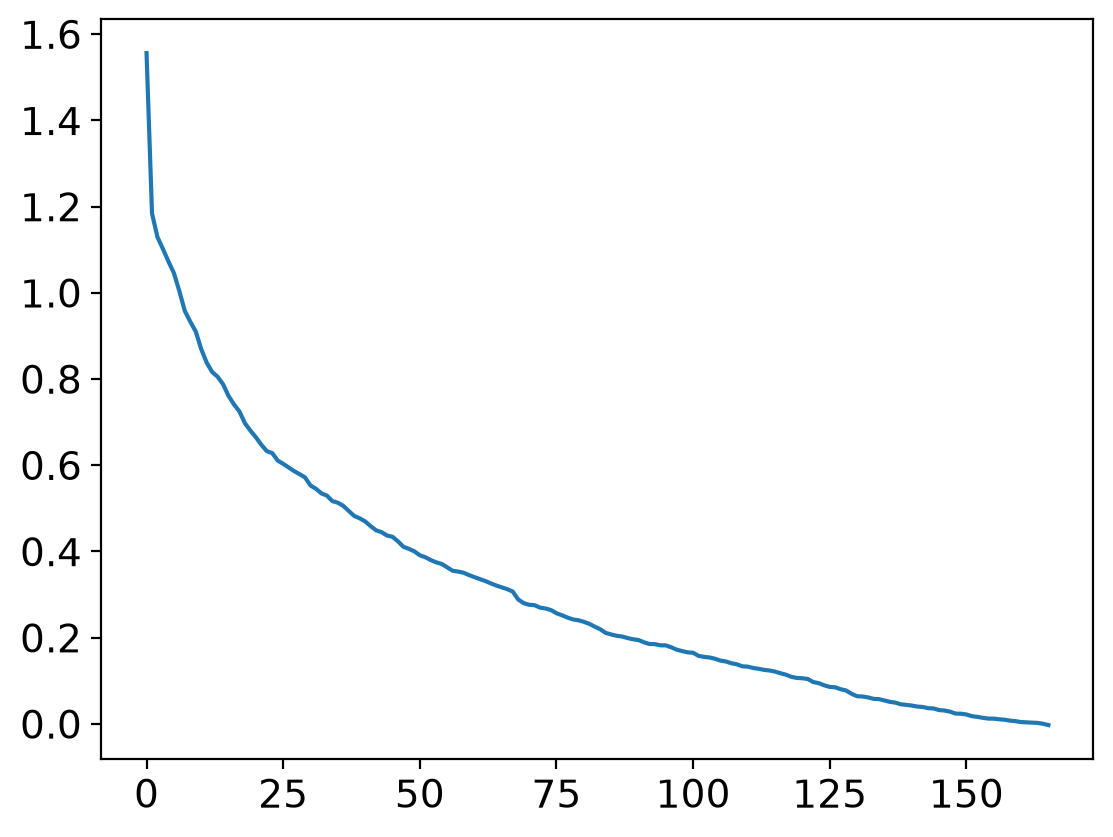

In [192]:
plt.plot(result.history.contour)


> Parametric Uncertainty

standard deviation 0.4811


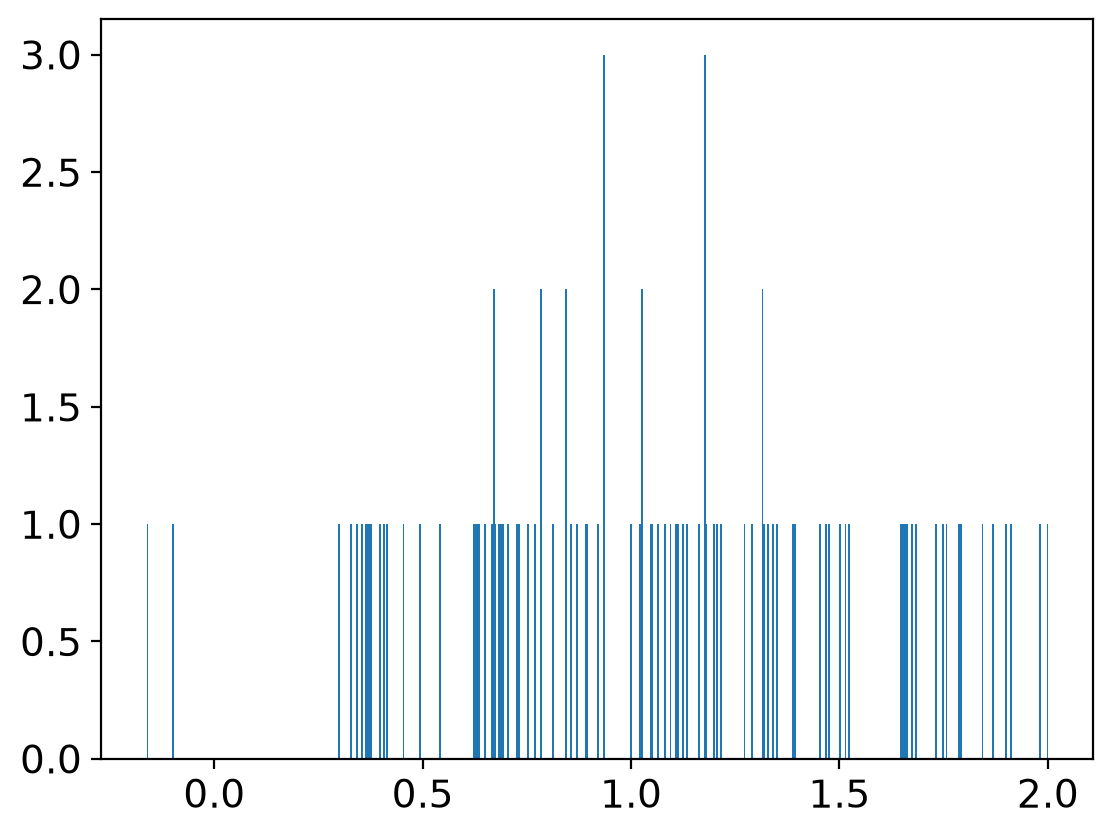

In [193]:
scenarios = np.random.default_rng(seed=0).normal(1.0, 0.5, size=(100, 1))
plt.hist(scenarios, 500)
print("standard deviation", np.round(np.std(scenarios), 4))

In [194]:
result = NestedSampler(constraints, lb=[-1, -1], ub=[1, 1], scenarios=scenarios, criterion="cvar", threshold=0.05, num_live=500).sample()


** INITIALIZING LIVE POINTS (500)      0.05 SEC

Iterate        Contour #Feas    #Dead         Factor
----------------------------------------------------
      0     2.1447e+00    50        0     3.0000e-01
     25     6.1066e-01    94      290     2.6725e-01
     50     4.0020e-01   136      481     2.4759e-01
     75     2.6395e-01   195      644     2.3196e-01
    100     1.6586e-01   251      792     2.1863e-01
    125     8.9392e-02   332      932     2.0672e-01
    150     2.3514e-02   431     1070     1.9562e-01
    166    -2.8158e-03   505     1150     1.8946e-01


(-1.0, 1.0)

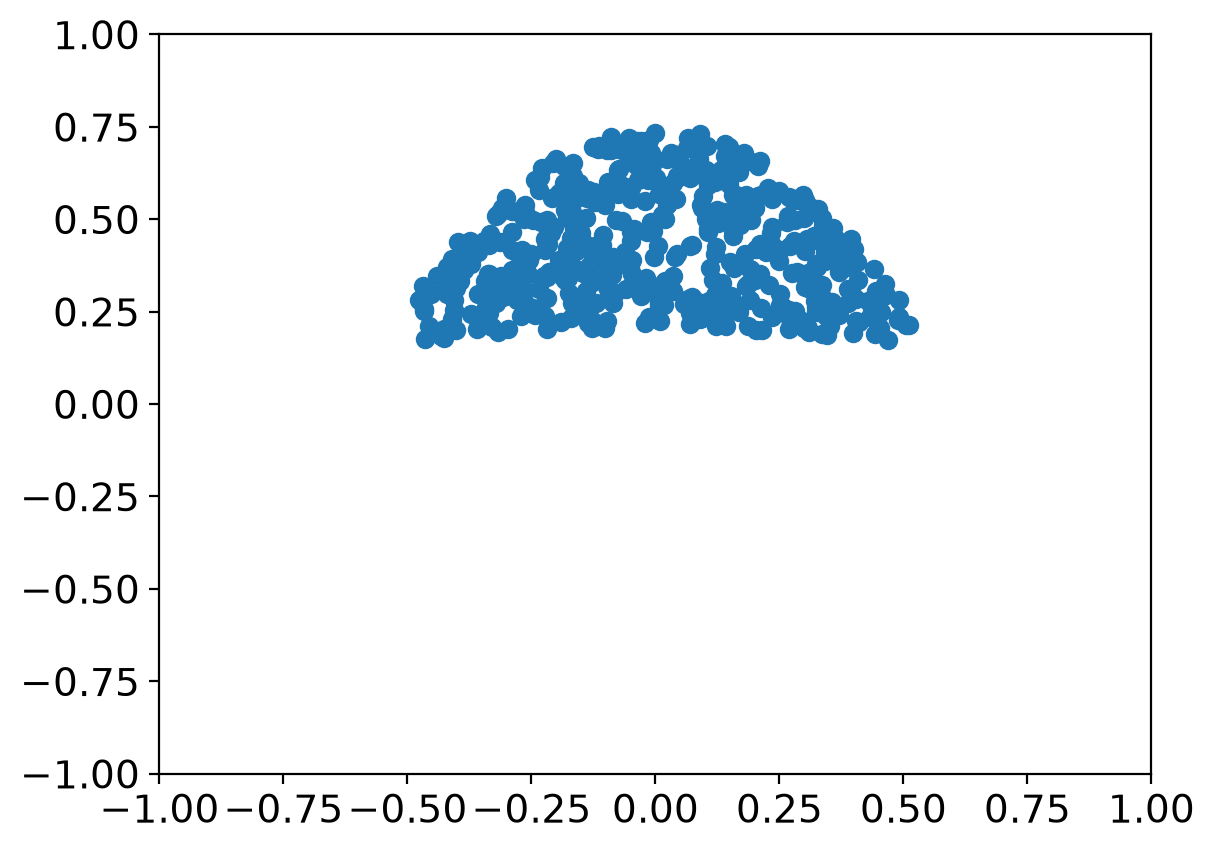

In [195]:
plt.scatter(result.live.x[:, 0], result.live.x[:, 1])
plt.xlim((-1, 1)); plt.ylim((-1, 1))


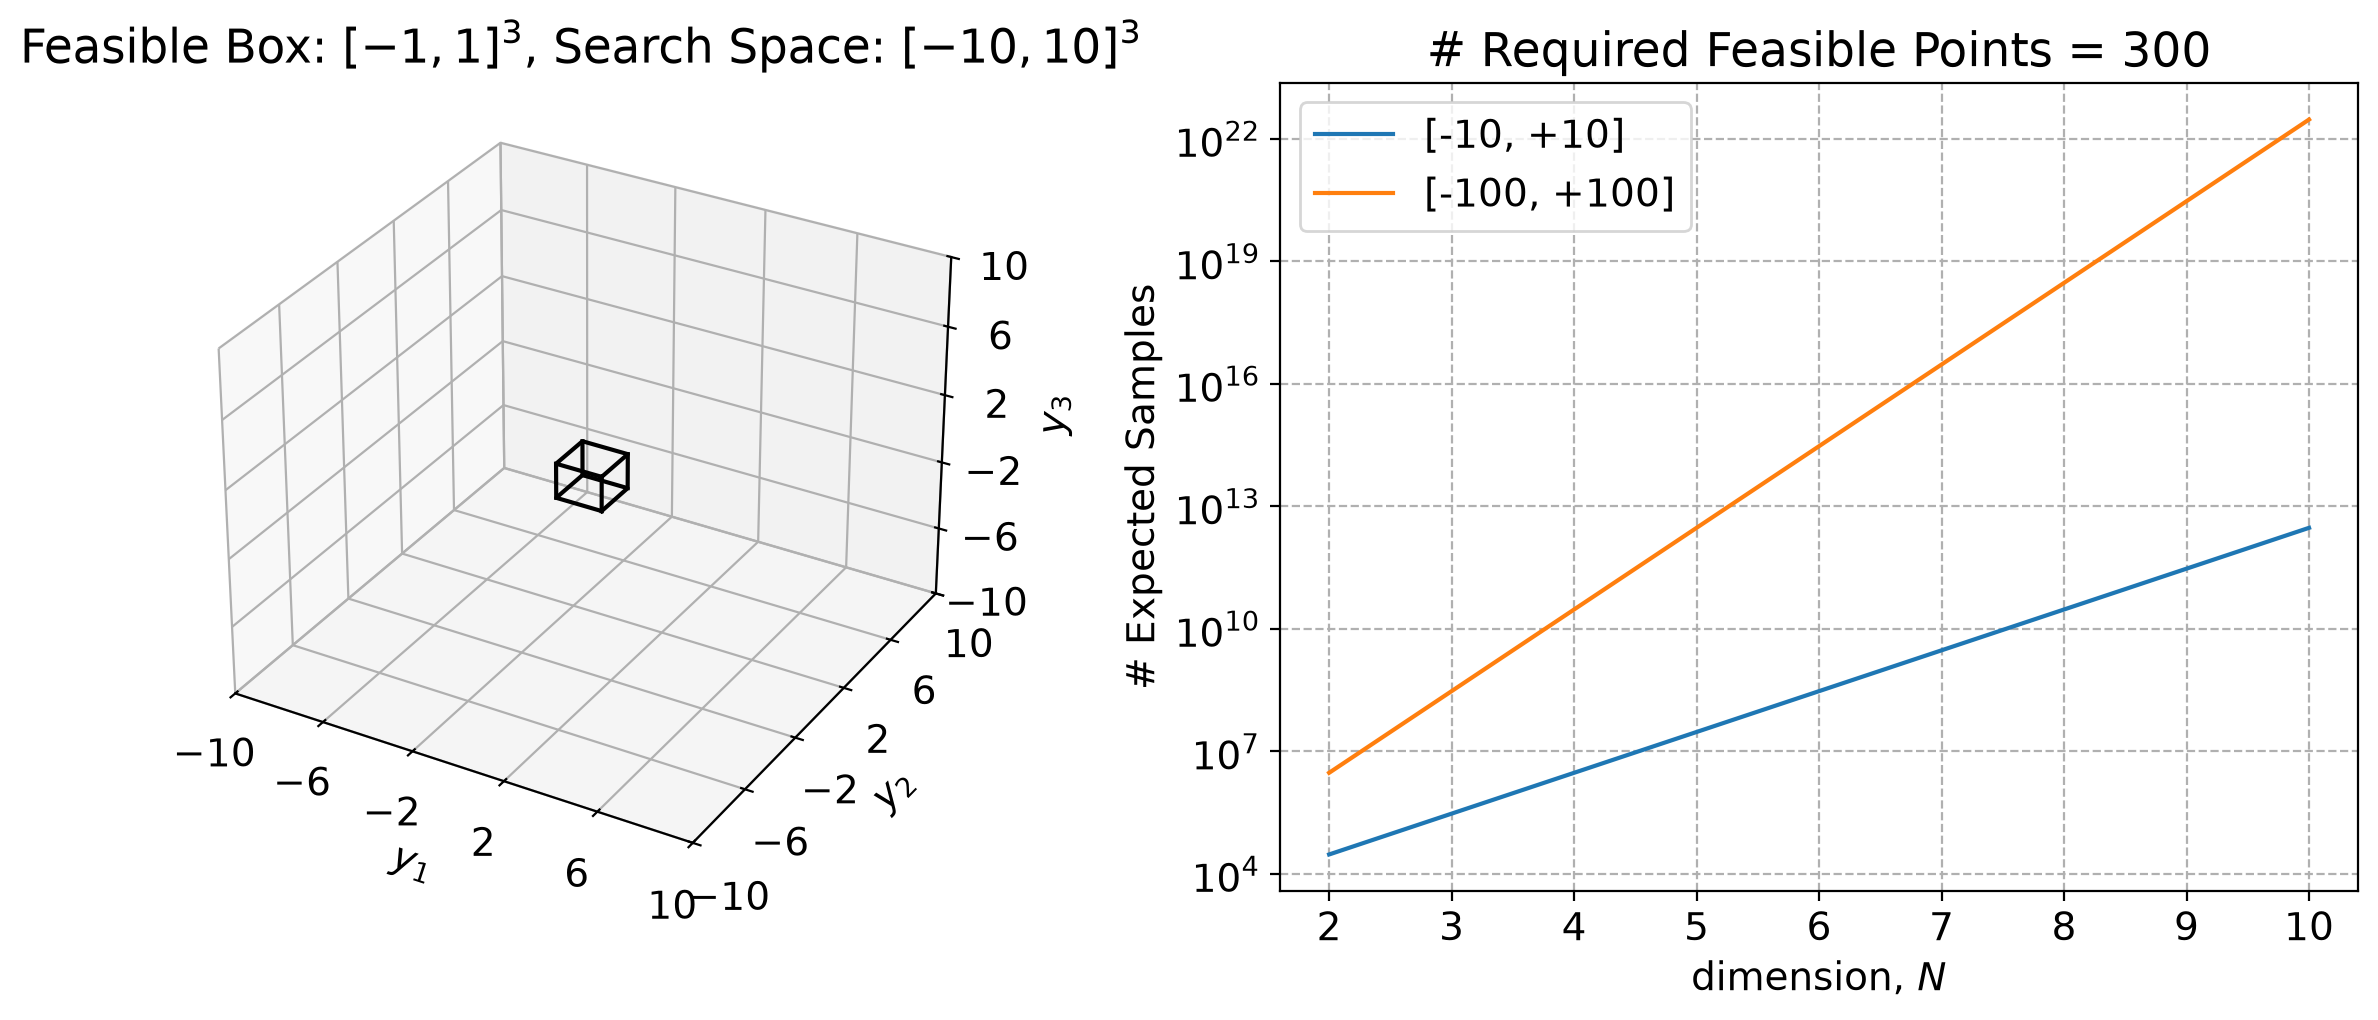

In [216]:
plt.rcParams["font.size"] = 14
fig = plt.figure(figsize=(12, 5))
ax0 = fig.add_subplot(1, 2, 1, projection="3d")
ax1 = fig.add_subplot(1, 2, 2)

ax0.set_xlim(-10, 10)
ax0.set_ylim(-10, 10)
ax0.set_zlim(-10, 10)
ax0.set_xticks(range(-10, 11,4))
ax0.set_yticks(range(-10, 11,4))
ax0.set_zticks(range(-10, 11,4))
ax0.set_xlabel("$y_1$")
ax0.set_ylabel("$y_2$")
ax0.set_zlabel("$y_3$")
# bottom edges
ax0.plot([1, 1, -1, -1, 1], [-1, 1, 1, -1, -1], [-1, -1, -1, -1, -1], color='k')
# vertical edges
ax0.plot([1, 1], [-1, -1], [-1, 1], color='k')
ax0.plot([1, 1], [1, 1], [-1, 1], color='k')
ax0.plot([-1, -1], [1, 1], [-1, 1], color='k')
ax0.plot([-1, -1], [-1, -1], [-1, 1], color='k')
# top edges
ax0.plot([1, 1, -1, -1, 1], [-1, 1, 1, -1, -1], [1, 1, 1, 1, 1], color='k')
ax0.set_title("Feasible Box: $[-1, 1]^3$, Search Space: $[-10, 10]^3$")

dim = np.arange(2, 11)
LIVE_REQ = 300
sam_20_span = LIVE_REQ / ((0.1) ** dim)
sam_200_span = LIVE_REQ / ((0.01) ** dim)

ax1.plot(dim, sam_20_span, label="[-10, +10]")
ax1.plot(dim, sam_200_span, label="[-100, +100]")
ax1.set_title("# Required Feasible Points = 300")
ax1.set_ylabel("# Expected Samples")
ax1.set_xlabel("dimension, $N$")
ax1.grid(True, linestyle='--')
ax1.set_yscale('log')
ax1.set_box_aspect(0.75)
ax1.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "Introduction/SampleScalingDimensionality", dpi=300, bbox_inches="tight")